In [1]:
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.time()
print('---------------------------------------')
print(time.strftime("PLS_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import tqdm
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.ndimage import median_filter
from pybaselines import Baseline
from sklearn.metrics import root_mean_squared_error
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
from matplotlib.patches import Ellipse
from matplotlib.backends.backend_pdf import PdfPages
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from functions_pixe import *
from polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.time()
elapsed_setup = (end_setup - start_setup)

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} s)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PLS_results.ipynb started: Thu, 16 Jul 2026 13:47:44
INFO: SETUP COMPLETE (8.9137 s)
---------------------------------------


In [2]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)

In [3]:
def typewriter(text, delay=0.05):
    for char in text:
        print(char, end='', flush=True)
        time.sleep(delay)
    
    print()
    time.sleep(1)

In [4]:
def signal_to_noise(signal, noise):
    P_signal = np.mean(np.array(signal)**2)
    P_noise = np.mean(np.array(noise)**2)
    snr = 10*np.log10(P_signal/P_noise)
    
    print(f'Signal-To-Noise Ration SNR = {snr:.2f}.')
    
    return snr 

In [ ]:
def SIMwise_Lambda_distribution(arpls_results, aspls_results, name, pdf, sim_vals):
    
    fig, ax = plt.subplots(figsize=(6,5), dpi=300)
    ax.scatter(arpls_results[:,0], arpls_results[:,1], marker='+', s=20, lw=0.5, alpha=1, zorder=3, color='black', label=r'arPLS $\lambda$-values')
    ax.scatter(aspls_results[:,0], aspls_results[:,1], marker='x', s=20, lw=0.5, alpha=1, zorder=3, color='black', label=r'asPLS $\lambda$-values')
    
    ax.grid(alpha=0.5, zorder=1)
    ax.set_ylim(0)
    
    results = [arpls_results,aspls_results]
    
    for i in range(len(results)):
        res = results[i]
        mean = np.mean(res, axis=0)
        cov = np.cov(res.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        
        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:,order]
        
        angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
        
        if i == 0:
            add_label = 'arPLS'
            c = 0
        else:
            add_label = 'asPLS'
            c = 4
        
        for n in [1,2,3]:
            width = 2 * n * np.sqrt(eigvals[0])
            height = 2 * n * np.sqrt(eigvals[1])
            
            if i == 0:
                ellipse = Ellipse(
                    xy = mean,
                    width = width,
                    height = height,
                    angle = angle,
                    fill = True,
                    alpha = 0.12,
                    zorder= 2,
                    color = color_schemes['c_light'][n],
                    label = f'{n}'+r'$\sigma$'
                )
            else:
                ellipse = Ellipse(
                    xy = mean,
                    width = width,
                    height = height,
                    angle = angle,
                    fill = True,
                    alpha = 0.12,
                    zorder= 2,
                    color = color_schemes['c_light'][n]
                )
            
            ax.add_patch(ellipse)
        
        ax.scatter(*mean, marker='o', color=color_schemes['c_complementary'][c], s=25, label=f'{add_label} mean value', zorder=3)
    
    
    ax.set_title(f'{len(results[0])} simulations of \n {sim_vals[0]} baseline with {sim_vals[1]} Gaussians and {sim_vals[2]} dB noise')
    ax.set_xlabel(r'smoothing parameter: $log_{10}\lambda$')
    ax.set_ylabel(r'root-mean-square error: $\rho(\lambda)$')
    
    ax.legend(ncols=2)
    plt.tight_layout()
    plt.savefig(f'./simulation/results/plots/{name}_lambda_dist_comb.png', dpi=300, transparent=False)
    pdf.savefig(dpi=300, transparent=False)
    # plt.show()
    plt.close(fig)
    return pdf

def lowest_point_in_rotated_ellipse(points, mean, width, height, angle):
    """
    points: (N,2) NumPy array
    theta: ellipse rotation in radians
    """
    cx, cy = mean[0], mean[1]
    # Translate to ellipse center
    dx = points[:, 0] - cx
    dy = points[:, 1] - cy

    # Rotate points by -theta (into ellipse coordinates)
    c = np.cos(angle)
    s = np.sin(angle)

    xr =  c * dx + s * dy
    yr = -s * dx + c * dy

    # Ellipse test
    inside = (xr / width) ** 2 + (yr / height) ** 2 <= 1

    if not np.any(inside):
        return None

    candidates = points[inside]
    return candidates[np.argmin(candidates[:, 1])]

def RUNwise_Lambda_distribution(results, which_pls, name, pdf, sim_vals):
    
    fig, ax = plt.subplots(figsize=(6,5), dpi=300)
    ax.scatter(results[:,0], results[:,1], marker='+', s=30, lw=0.5, alpha=1, zorder=3, color='black', label=rf'{which_pls} $\lambda$-values ({name})')
    
    ax.grid(alpha=0.5, zorder=1)
    ax.set_ylim(0)
    

    res = results
    mean = np.mean(res, axis=0)
    cov = np.cov(res.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:,order]
    
    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
    
    sigma_min = {}
    
    ellipse = {}
    
    for n in [1,2,3]:
        width = 2 * n * np.sqrt(eigvals[0])
        height = 2 * n * np.sqrt(eigvals[1])
        
        j = [1,6,3]
        
        sigma_min[n] = lowest_point_in_rotated_ellipse(results, mean, width/2, height/2, np.radians(angle))
        
        if sigma_min[n] is None:
            ax.scatter([], [], marker='+', s=30, lw=0.6, alpha=1, zorder=3, color = color_schemes['c_rainbow'][j[n-1]], label=rf'{n}$\sigma: \lambda$ = x / $\rho$ = x')
        else:
            ax.scatter(sigma_min[n][0], sigma_min[n][1], marker='+', s=30, lw=0.6, alpha=1, zorder=3, color = color_schemes['c_rainbow'][j[n-1]], label=rf'{n}$\sigma: \lambda$ = {round(sigma_min[n][0],2)} / $\rho$ =  {round(sigma_min[n][1],2)}')
            
        ellipse[n] = Ellipse(
            xy = mean,
            width = width,
            height = height,
            angle = angle,
            fill = True,
            alpha = 0.20,
            zorder= 2,
            color = color_schemes['c_light'][n],
            label = f'{n}' + r'$\sigma$'
        )

        
    
    
    
    idx = np.argmin(results[:,1])
    sigma_min[4] = [results[idx,0], results[idx,1]]
    ax.scatter(*mean, marker='o', s=25, color='black', label='mean value', zorder=3)
    ax.scatter(results[idx,0], results[idx,1], marker='s', s=25, lw=0.6, alpha=1, zorder=2, color='black', label=rf'global min.: $\lambda$ = {round(results[idx,0],2)} / $\rho$ =  {round(results[idx,1],2)}')
    
    ax.add_patch(ellipse[1])
    ax.add_patch(ellipse[2])
    ax.add_patch(ellipse[3])
    
    ax.set_title(f'{len(results)} {which_pls} fits of \n {sim_vals[0]} baseline with {sim_vals[1]} Gaussians and {sim_vals[2]} dB noise')
    ax.set_xlabel(r'smoothing parameter: $log_{10}\lambda$')
    ax.set_ylabel(r'root-mean-square error: $\rho(\lambda)$')
    
    ax.legend(ncols=2)
    
    
    plt.tight_layout()
    plt.savefig(f'./simulation/results/plots/{name}_lambda_dist_{which_pls}.png', dpi=300, transparent=False)
    pdf.savefig(dpi=300, transparent=False)
    # plt.show()
    plt.close(fig)
    pdf.close()
    return pdf, sigma_min
        

In [ ]:
def filewise_data_overview(filename:str, sigma_mins:dict):
    
    simulation_data = read_json_formatted_file(filename)
    
    try:
        arpls_lamb = [item[1]['arpls_lambda'] for item in simulation_data] # arPLS x-values
    except:
        arpls_lamb = [item[1]['arpls_lambda_min'] for item in simulation_data] # arPLS x-values
    
    try:
        aspls_lamb = [item[1]['aspls_lambda'] for item in simulation_data] # asPLS x-values
    except:
        aspls_lamb = [item[1]['aspls_lambda_min'] for item in simulation_data] # asPLS x-values
        
    try:    
        arpls_rmse = [item[1]['arpls_rmse'] for item in simulation_data]
    except:
        arpls_rmse = [item[1]['arpls_rmse_min'] for item in simulation_data]  
        
    try:
        aspls_rmse = [item[1]['aspls_rmse'] for item in simulation_data]
    except:
        try:
            aspls_rmse = [item[1]['aspls_rmse_min'] for item in simulation_data]
        except:
            aspls_rmse = [np.min(item[1]['aspls_rmse_all']) for item in simulation_data]
    
    arpls_results = np.column_stack([arpls_lamb,arpls_rmse])
    aspls_results = np.column_stack([aspls_lamb, aspls_rmse])
    
    snr_value = simulation_data[0][0]['SNR'] # snr = signal to noise ratio
    nog_value = simulation_data[0][0]['NumberOfPeaks'] # nog = number of gaussians
    blt_value = simulation_data[0][0]['BaselineType'] # blt = baseline type
    
    sim_values = [blt_value,nog_value,snr_value]
    # typewriter(f'Simulation of {nog_value} gaussians on a {blt_value} background with an SNR = {snr_value}.')
    
    short_name = f'{filename.split('_')[5]}_{filename.split('_')[6][:-5]}'

    with PdfPages(f'./simulation/results/plots/lambdadist_{short_name}.pdf') as pdf:
        pdf = SIMwise_Lambda_distribution(arpls_results, aspls_results, name=short_name, pdf=pdf, sim_vals=sim_values)
        pdf, sigma_min_arpls = RUNwise_Lambda_distribution(arpls_results, 'arPLS', name=short_name, pdf=pdf, sim_vals=sim_values)
        _, sigma_min_aspls = RUNwise_Lambda_distribution(aspls_results, 'asPLS', name=short_name, pdf=pdf, sim_vals=sim_values)
    
    sigma_mins[f'{short_name}_arpls'] = [sigma_min_arpls,blt_value,nog_value,snr_value]
    sigma_mins[f'{short_name}_aspls'] = [sigma_min_aspls,blt_value,nog_value,snr_value]
    
    return sigma_mins
    
    

In [ ]:
import gc

def generate_plot(filename):
    simulation_data = read_json_formatted_file(filename)
    
    short_name = f'{filename.split('_')[5]}_{filename.split('_')[6][:-5]}'

    snr_value = simulation_data[0][0]['SNR'] # snr = signal to noise ratio
    nog_value = simulation_data[0][0]['NumberOfPeaks'] # nog = number of gaussians
    blt_value = simulation_data[0][0]['BaselineType'] # blt = baseline type
    
    with PdfPages(f'./simulation/results/plots/toymodeldata_{short_name}.pdf') as pdf:
        for i in range(len(simulation_data)):
            fig, ax = plt.subplots(figsize=(9,4), dpi=300)
            sd_min = np.min(simulation_data[i][0]['SyntheticData'])
            bl_min = np.min(simulation_data[i][0]['Baseline'])
            if (sd_min < bl_min):        
                ax.plot(simulation_data[i][0]['Bins'], simulation_data[i][0]['SyntheticData'] - sd_min, lw=0.5, alpha=1, zorder=2, color='black', label=f'SNR: {snr_value} dB \n No. Gaussian: {nog_value} \n Baseline: {blt_value}')
                ax.plot(simulation_data[i][0]['Bins'], simulation_data[i][0]['Baseline'] - sd_min, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label='Baseline')
            elif (sd_min > bl_min):        
                ax.plot(simulation_data[i][0]['Bins'], simulation_data[i][0]['SyntheticData'] - bl_min, lw=0.5, alpha=1, zorder=2, color='black', label=f'SNR: {snr_value} dB \n No. Gaussian: {nog_value} \n Baseline: {blt_value}')
                ax.plot(simulation_data[i][0]['Bins'], simulation_data[i][0]['Baseline'] - bl_min, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label='Baseline')
            
            ax.set_xlabel('Bins')
            ax.set_ylabel('Counts')
            
            ax.grid(alpha=0.5, zorder=1)
            ax.set_ylim(800)
            # if np.min(simulation_data[i][0]['SyntheticData']) <= 0:
            #     ax.set_yscale('linear')
            # else:
            ax.set_yscale('log')
            ax.legend()
            plt.tight_layout()
            pdf.savefig(dpi=300, transparent=False)
            plt.close(fig)
        del simulation_data
        pdf.close()
        gc.collect()
    
    
    
            

### simulation_data structure

simulation_data[ i ][ j ][ keys ]

- i: number of experiments: = len(simulation_data) = 100 for most
- j: 
  - 0: toy model data
  - 1: PLS method data
- keys:
  - if j = 0: 'Bins', 'NumberOfPeaks', 'SNR', 'GaussianPeaks', 'Noise', 'BaselineType', 'BaselineParameter', 'Baseline', 'SyntheticData'
  - if j = 1: 'arpls_lambda', 'arpls_rmse', 'aspls_lambda', 'aspls_rmse' (each optimal parameters for given toy model)

In [ ]:
# filepath = './simulation/toy_model_data/toy_model_run_150626_232426.json'
# filepath = './simulation/toy_model_data/toy_model_run_250626_201217.json'
# simulation_data = read_json_formatted_file(filepath)
# x = filewise_data_overview(filename=filepath, sigma_mins={})
# print(x)


In [ ]:
def run_all_files():
    all_sigmas = {}
    for file in tqdm.tqdm(os.listdir('./simulation/toy_model_data/')):
        filepath = f'./simulation/toy_model_data/{file}'
        if os.path.isfile(filepath):
            # print(filepath)
            date = filepath.split('_')[5]
            idx = date[4] + date[5] + date[2] + date[3] + date[0] + date[1]
            # print(int(idx))
            if int(idx) < 260624:
                all_sigmas = filewise_data_overview(filename=filepath, sigma_mins=all_sigmas)
            else:
                all_sigmas = filewise_data_overview(filename=filepath, sigma_mins=all_sigmas)
    return all_sigmas



# all_sigmas = run_all_files()
# print(all_sigmas)
# date_str = time.strftime("%d_%b_%Y", time.localtime())
# json_file_name = f'./simulation/results/sigmas/{date_str}_sigmas.json'
# with open(json_file_name, 'w', encoding='utf-8') as json_file:
#     json.dump(all_sigmas, json_file, cls=NumpyEncoder, indent=2)
# print('RESULTS SAVED: json file done.')

In [ ]:
def generate_all_toyplots():
    for file in tqdm.tqdm(os.listdir('./simulation/toy_model_data/')):
        filepath = f'./simulation/toy_model_data/{file}'
        if os.path.isfile(filepath):
            generate_plot(filepath)
    

In [ ]:
# filepath = './simulation/toy_model_data/toy_model_run_250626_201217.json'
# generate_plot(filepath)

# generate_all_toyplots()

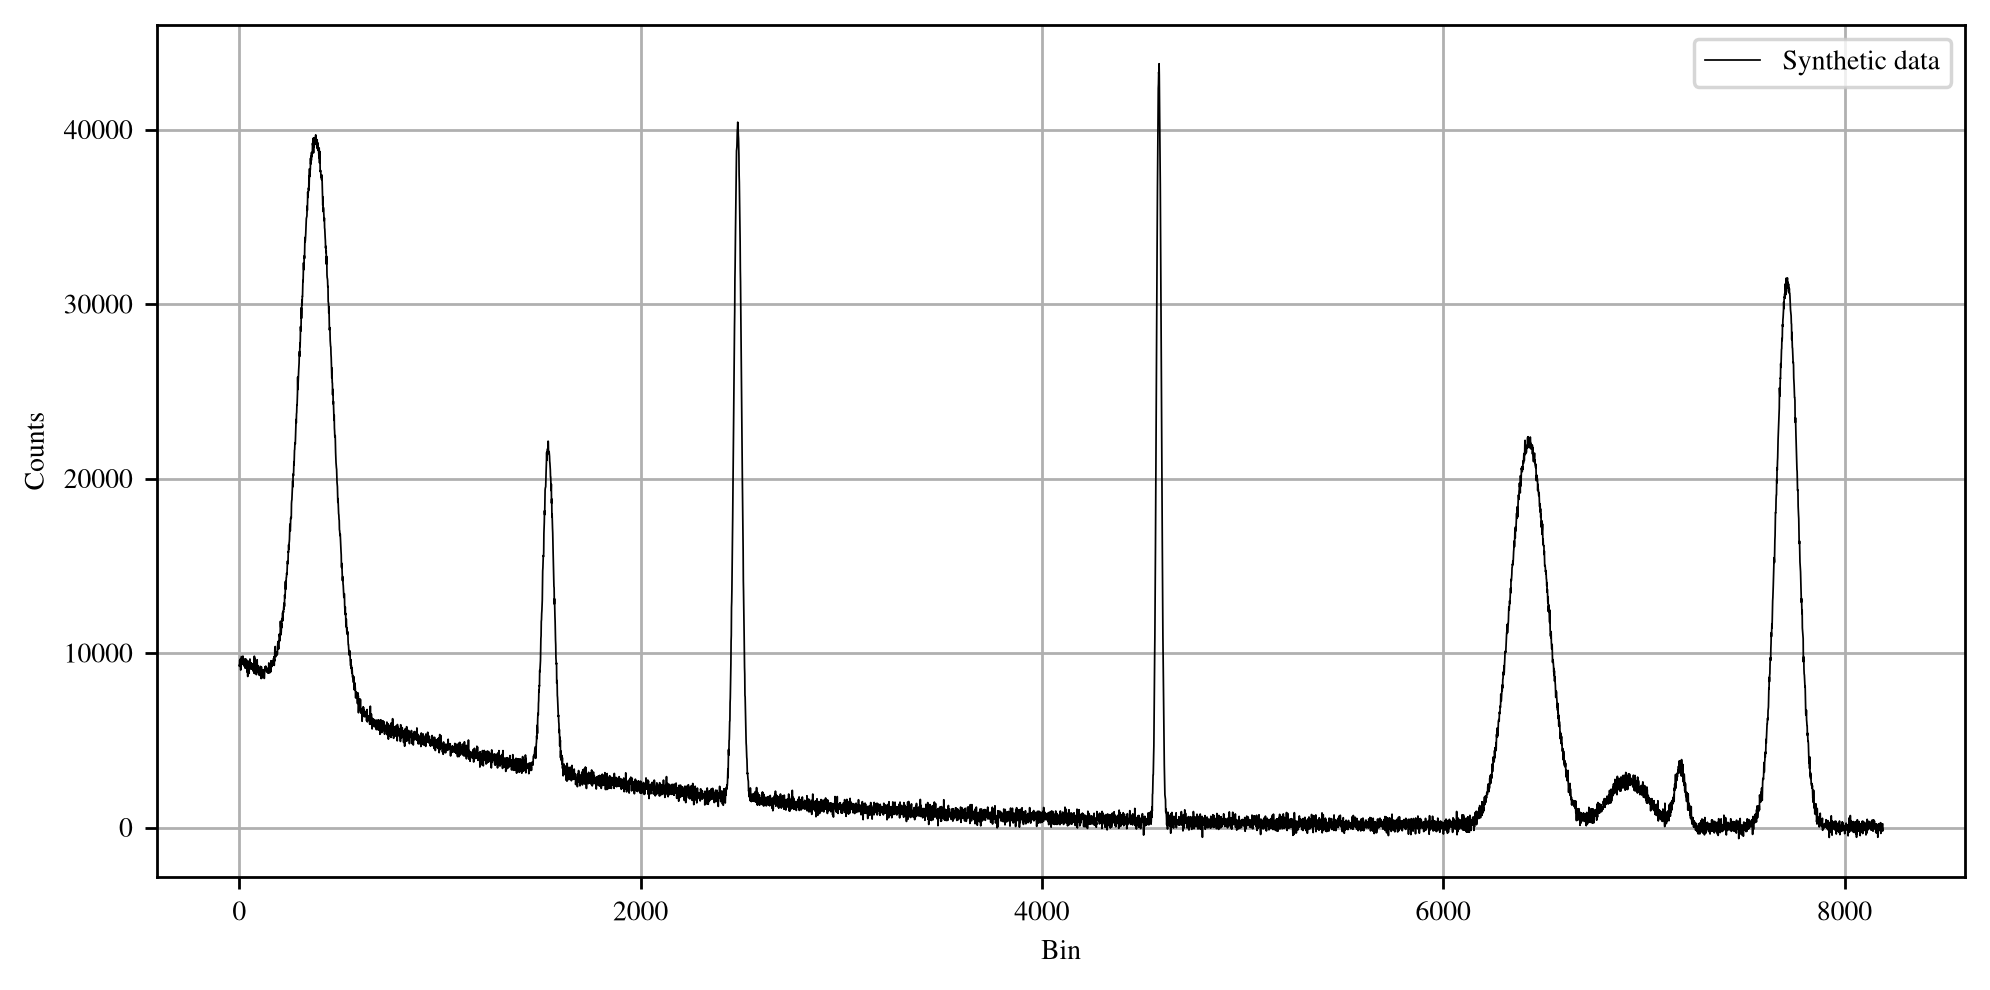

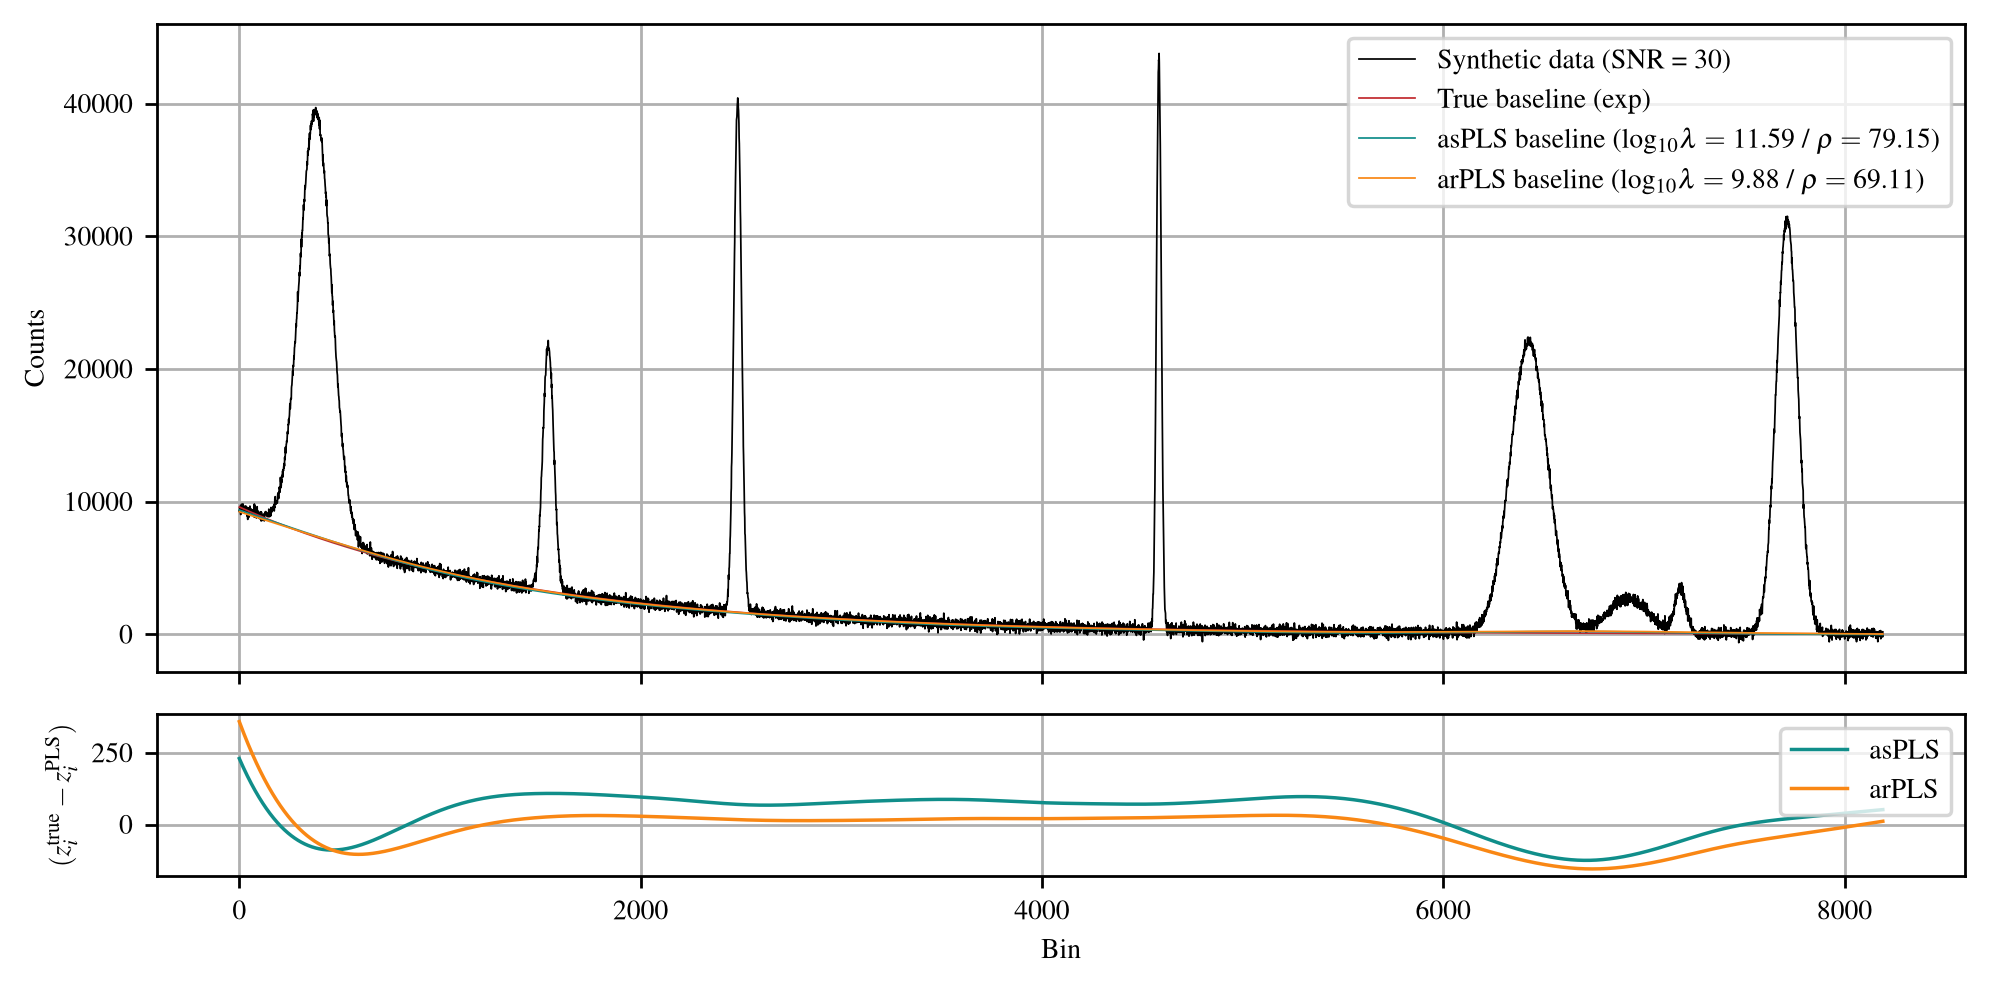

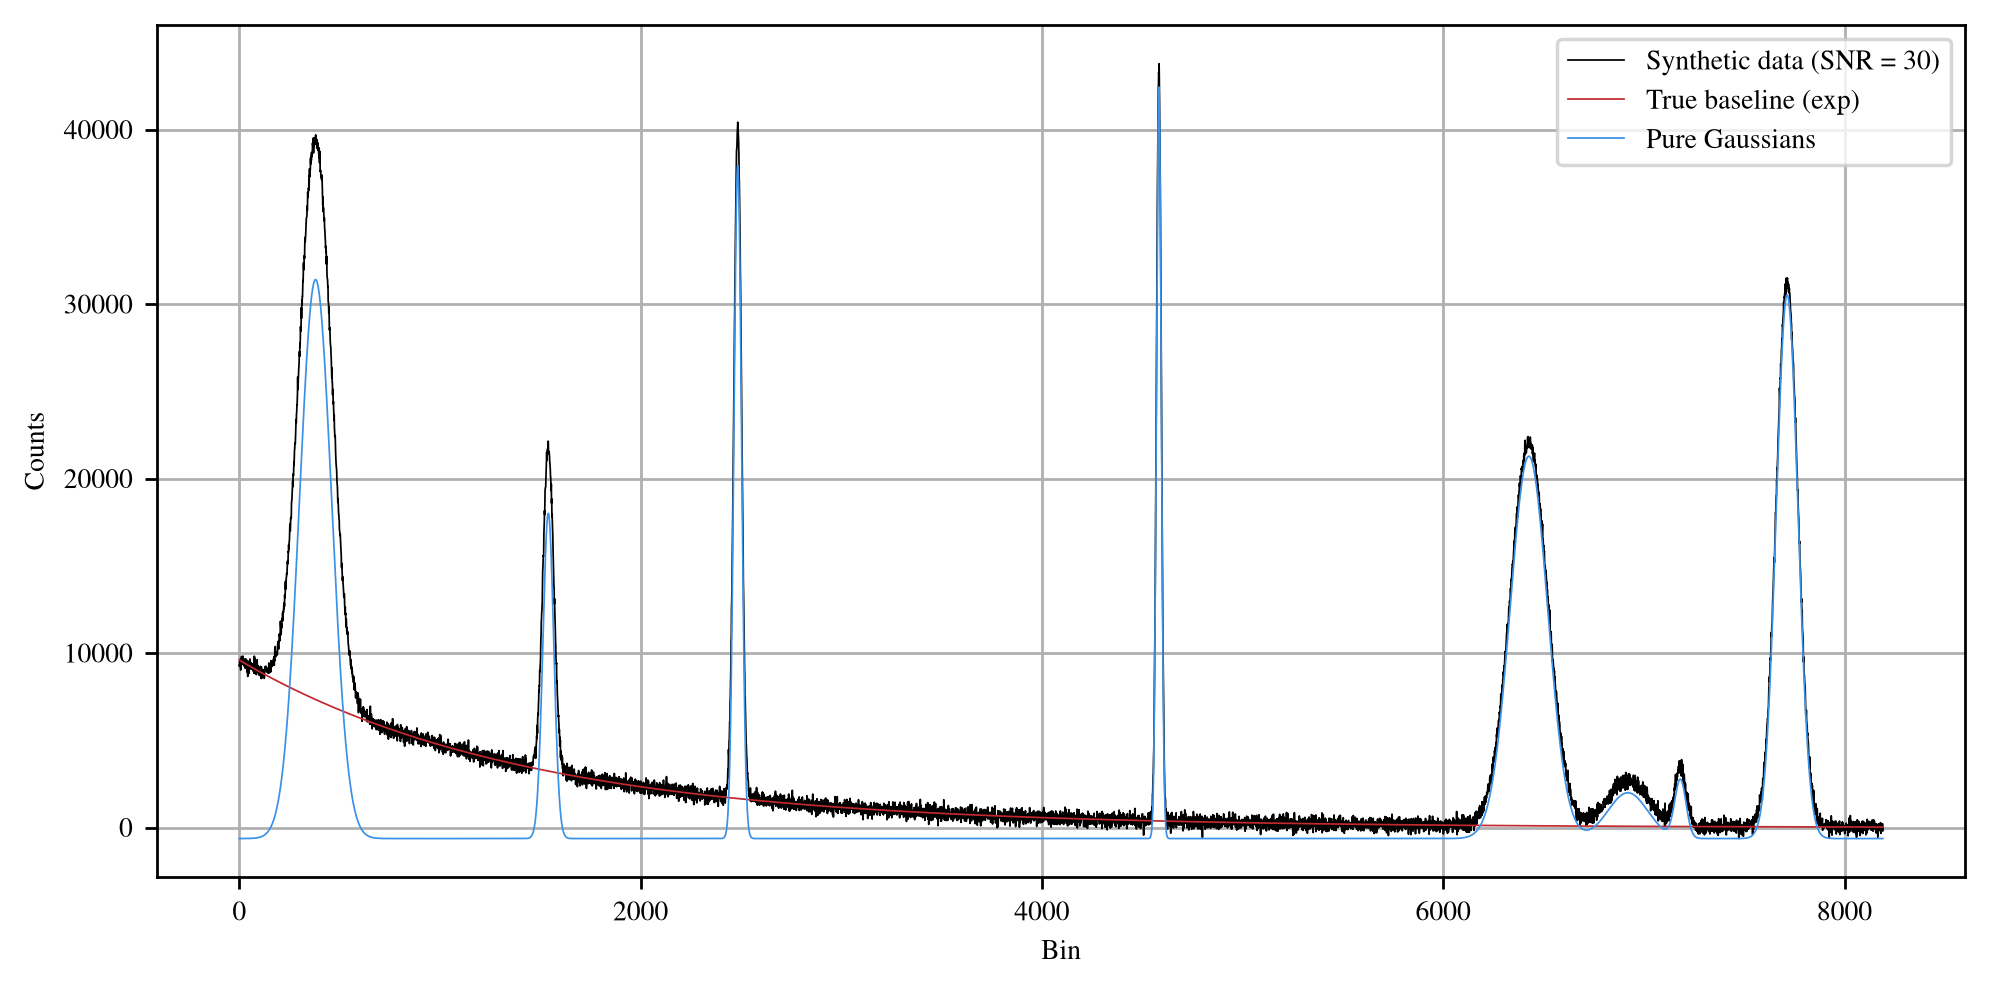

In [100]:
# filename = './simulation/toy_model_data/toy_model_run_150626_084926.json' #8 Gauss, Lin BLT
# filename = './simulation/toy_model_data/toy_model_run_260626_004227.json' #8 Gauss, Poly 4 BLT
# filename = './simulation/toy_model_data/toy_model_run_260626_121830.json' #8 Gauss, Poly 3 BLT
# filename = './simulation/toy_model_data/toy_model_run_260626_073006.json' #8 Gauss, Poly 2 BLT
# filename = './simulation/toy_model_data/toy_model_run_250626_195259.json' #8 Gauss, Poly 1 BLT
# filename = './simulation/toy_model_data/toy_model_run_270626_134642.json' #8 Gauss, Sine BLT
filename = './simulation/toy_model_data/toy_model_run_270626_183508.json' #8 Gauss, exp BLT
index = filename.split('.')[1].split('_run_')[1]
simulation_data = read_json_formatted_file(filename)
rng = np.random.default_rng()
# which = int(rng.integers(low=0, high=99))
# print(which)
which = 30 #6,32,47,62,85,21,30
tmd_syn = simulation_data[which][0]
tmd_pls = simulation_data[which][1]
snr_value = simulation_data[which][0]['SNR'] # snr = signal to noise ratio
nog_value = simulation_data[which][0]['NumberOfPeaks'] # nog = number of gaussians
blt_value = simulation_data[which][0]['BaselineType'] # blt = baseline type
op_value = len(simulation_data[which][0]['BaselineParameter'])-1
bsl_fitter = Baseline(x_data=tmd_syn['Bins'])
try:
    bsl_aspls,_ = bsl_fitter.aspls(tmd_syn['SyntheticData'], lam=10**(float(tmd_pls['aspls_lambda'])), max_iter=500)
    bsl_arpls,_ = bsl_fitter.arpls(tmd_syn['SyntheticData'], lam=10**(float(tmd_pls['arpls_lambda'])), max_iter=500)
    print(tmd_pls['aspls_lambda'])
    lam_as = float(tmd_pls['aspls_lambda'])
    lam_ar = float(tmd_pls['arpls_lambda'])
except:
    bsl_aspls,_ = bsl_fitter.aspls(tmd_syn['SyntheticData'], lam=10**(float(tmd_pls['aspls_lambda_min'])), max_iter=500)
    bsl_arpls,_ = bsl_fitter.arpls(tmd_syn['SyntheticData'], lam=10**(float(tmd_pls['arpls_lambda_min'])), max_iter=500)
    lam_as = float(tmd_pls['aspls_lambda_min'])
    lam_ar = float(tmd_pls['arpls_lambda_min'])
try:
    rho_as = tmd_pls['aspls_rmse']
    rho_ar = tmd_pls['arpls_rmse']
except:
    rho_as = tmd_pls['aspls_rmse_min']
    rho_ar = tmd_pls['arpls_rmse_min']

plt.figure(figsize=(8,4), dpi=250)
plt.plot(tmd_syn['Bins'], tmd_syn['SyntheticData'], lw=0.5, alpha=1, zorder=2, color='black', label='Synthetic data')
# plt.plot(tmd_syn['Bins'], tmd_syn['Baseline'], lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label='True baseline')
# plt.plot(tmd_syn['Bins'], bsl_aspls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][1], label='asPLS baseline')
# plt.plot(tmd_syn['Bins'], bsl_arpls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][5], label='arPLS baseline')

plt.xlabel('Bin')
plt.ylabel('Counts')

plt.grid(which='both')
plt.legend()
plt.yscale('linear')
plt.tight_layout()
plt.savefig(f'./export/{index}_{which}_1.png', transparent=False)
plt.show()

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1,figsize=(8, 4), dpi=250,gridspec_kw={'height_ratios': [4, 1]}, sharex=True)  # upper : lower = 5 : 1  => lower is 1/5 height
ax1.plot(tmd_syn['Bins'], tmd_syn['SyntheticData'], lw=0.5, alpha=1, zorder=2, color='black', label=f'Synthetic data (SNR = {snr_value})')

if blt_value == 'poly':
    ax1.plot(tmd_syn['Bins'], tmd_syn['Baseline'], lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label=f'True baseline ({blt_value} / order {op_value})')
else:
    ax1.plot(tmd_syn['Bins'], tmd_syn['Baseline'], lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label=f'True baseline ({blt_value})')
ax1.plot(tmd_syn['Bins'], bsl_aspls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][1], label=r'asPLS baseline (log$_{10}\lambda = $' + f' {round(lam_as,2)} /' + r' $\rho = $' + f' {round(rho_as,2)})')
ax1.plot(tmd_syn['Bins'], bsl_arpls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][5], label=r'arPLS baseline (log$_{10}\lambda = $' + f' {round(lam_ar,2)} /' + r' $\rho = $' + f' {round(rho_ar,2)})')
ax2.plot(tmd_syn['Bins'], tmd_syn['Baseline'] - bsl_aspls, lw=1, alpha=1, zorder=3, color=color_schemes['c_light'][1], label='asPLS')
ax2.plot(tmd_syn['Bins'], tmd_syn['Baseline'] - bsl_arpls, lw=1, alpha=1, zorder=3, color=color_schemes['c_light'][5], label='arPLS')
ax1.grid(which='both')
ax2.grid(which='both')

ax1.set_yscale('linear')
# ax2.set_ylim(-20,100)

ax2.set_xlabel('Bin')
ax1.set_ylabel('Counts')
ax2.set_ylabel(r'$(z_i^{\mathrm{true}} - z_i^{\mathrm{PLS}})$')

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.savefig(f'./export/{index}_{which}_2.png', transparent=False)
plt.show()

plt.figure(figsize=(8,4), dpi=250)
plt.plot(tmd_syn['Bins'], tmd_syn['SyntheticData'], lw=0.5, alpha=1, zorder=2, color='black', label=f'Synthetic data (SNR = {snr_value})')
if blt_value == 'poly':
    plt.plot(tmd_syn['Bins'], tmd_syn['Baseline'], lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label=f'True baseline ({blt_value} / order {op_value})')
else:
    plt.plot(tmd_syn['Bins'], tmd_syn['Baseline'], lw=0.5, alpha=1, zorder=3, color=color_schemes['c_rainbow'][1], label=f'True baseline ({blt_value})')

if np.min(tmd_syn['SyntheticData']) < 0:
    plt.plot(tmd_syn['Bins'], multi_gauss(tmd_syn['GaussianPeaks'],np.array(tmd_syn['Bins'])) - np.abs(np.min(tmd_syn['SyntheticData'])), lw=0.5, alpha=1, zorder=3, color=color_schemes['c_complementary'][4], label='Pure Gaussians')
else:
    plt.plot(tmd_syn['Bins'], multi_gauss(tmd_syn['GaussianPeaks'],np.array(tmd_syn['Bins'])), lw=0.5, alpha=1, zorder=3, color=color_schemes['c_complementary'][4], label='Pure Gaussians')
# plt.plot(tmd_syn['Bins'], bsl_aspls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][1], label='asPLS baseline')
# plt.plot(tmd_syn['Bins'], bsl_arpls, lw=0.5, alpha=1, zorder=3, color=color_schemes['c_light'][5], label='arPLS baseline')
plt.grid(which='both')
plt.legend()
plt.xlabel('Bin')
plt.ylabel('Counts')
plt.yscale('linear')
plt.tight_layout()
plt.savefig(f'./export/{index}_{which}_3.png', transparent=False)
plt.show()

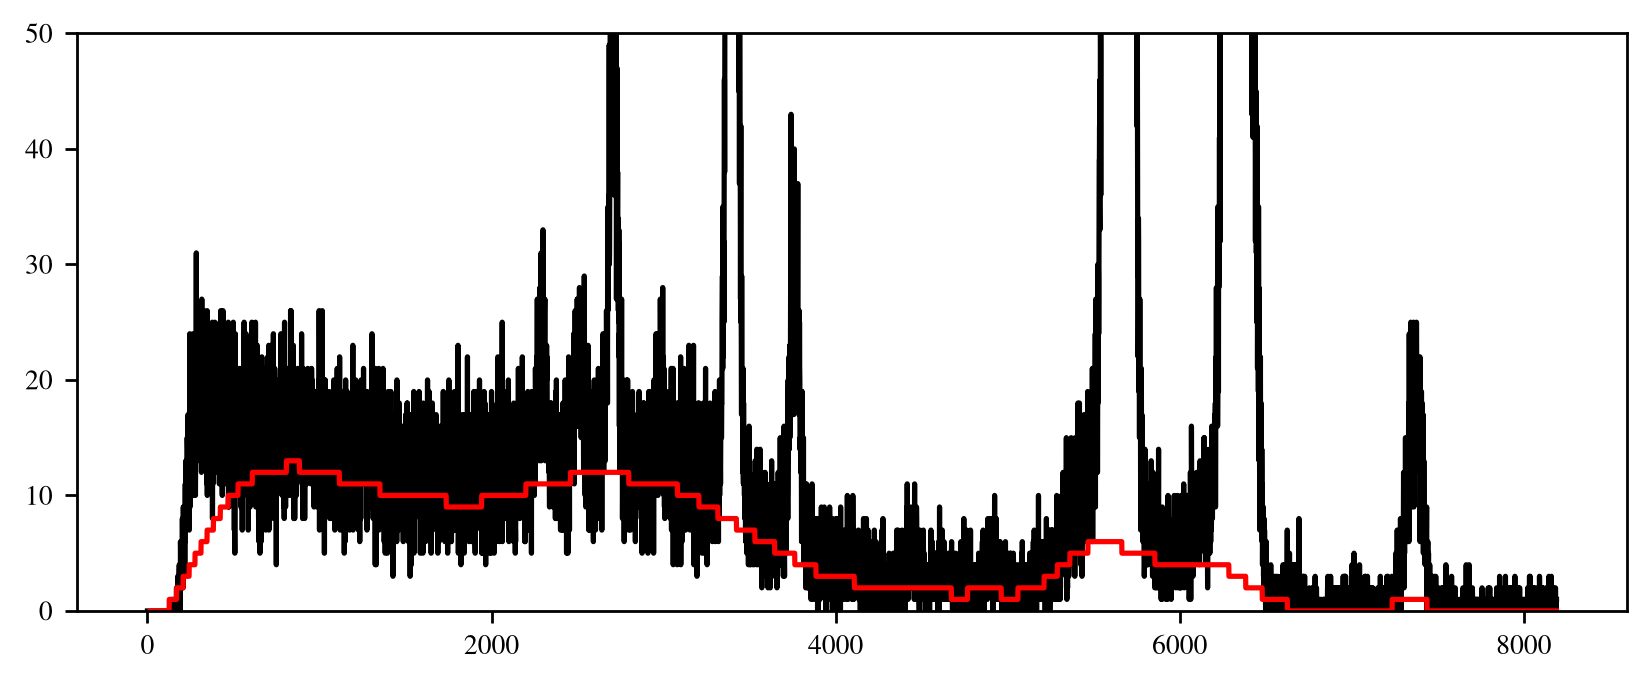

In [117]:
filename = './spectra/20260325-081734.vspc'
data = read_json_formatted_file(filename)
spectrum = data['RawData'][:-1]
bins = np.arange(0,8191,1)
bsl_fitter = Baseline(x_data=bins)
bsl_aspls,_ = bsl_fitter.aspls(spectrum, lam=10**11, max_iter=500)

plt.figure(figsize=(8,3), dpi=250)
plt.plot(bins, spectrum, color='black')
plt.plot(bins,bsl_aspls, color='red')
plt.ylim(0,50)
# plt.yscale('log')
plt.show()